# Layer 7 – Prophet Spare Forecasting

Industry-grade training notebook with data engineering, visualization, training, and evaluation.

## 1. Environment Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nb_dir = Path.cwd()
project = nb_dir
while project.parent != project:
    if (project / "backend" / "main.py").exists():
        break
    project = project.parent
backend = project / "backend"
for p in (project, backend):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

ARTIFACTS = backend / "artifacts"
DATA = project / "data"
DATASETS = DATA / "datasets"
MASTER = DATA / "master"
EVAL = DATA / "evaluation"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

from scripts.synthetic_data import load_dataset, persist_all_datasets
if not (MASTER / "industrial_master.csv").exists():
    persist_all_datasets(DATASETS)

MODEL_KEY = "prophet_forecast"
TRAIN_CSV = DATASETS / MODEL_KEY / "train.csv"
TEST_CSV  = DATASETS / MODEL_KEY / "test.csv"
train_npz = load_dataset(MODEL_KEY, DATASETS, split="train")
test_npz  = load_dataset(MODEL_KEY, DATASETS, split="test")
print("Project:", project)
print("Train shape:", train_npz["X"].shape)
print("Test shape:", test_npz["X"].shape)
sns.set_theme(style="whitegrid")

Project: c:\Users\ASUS\Downloads\tata-steel-round -2\industrial-agentic-maintenance-ai
Train shape: (2167,)
Test shape: (2167,)


## 2. Data Engineering & Exploratory Analysis

Master records: 52,000 | Assets: 520


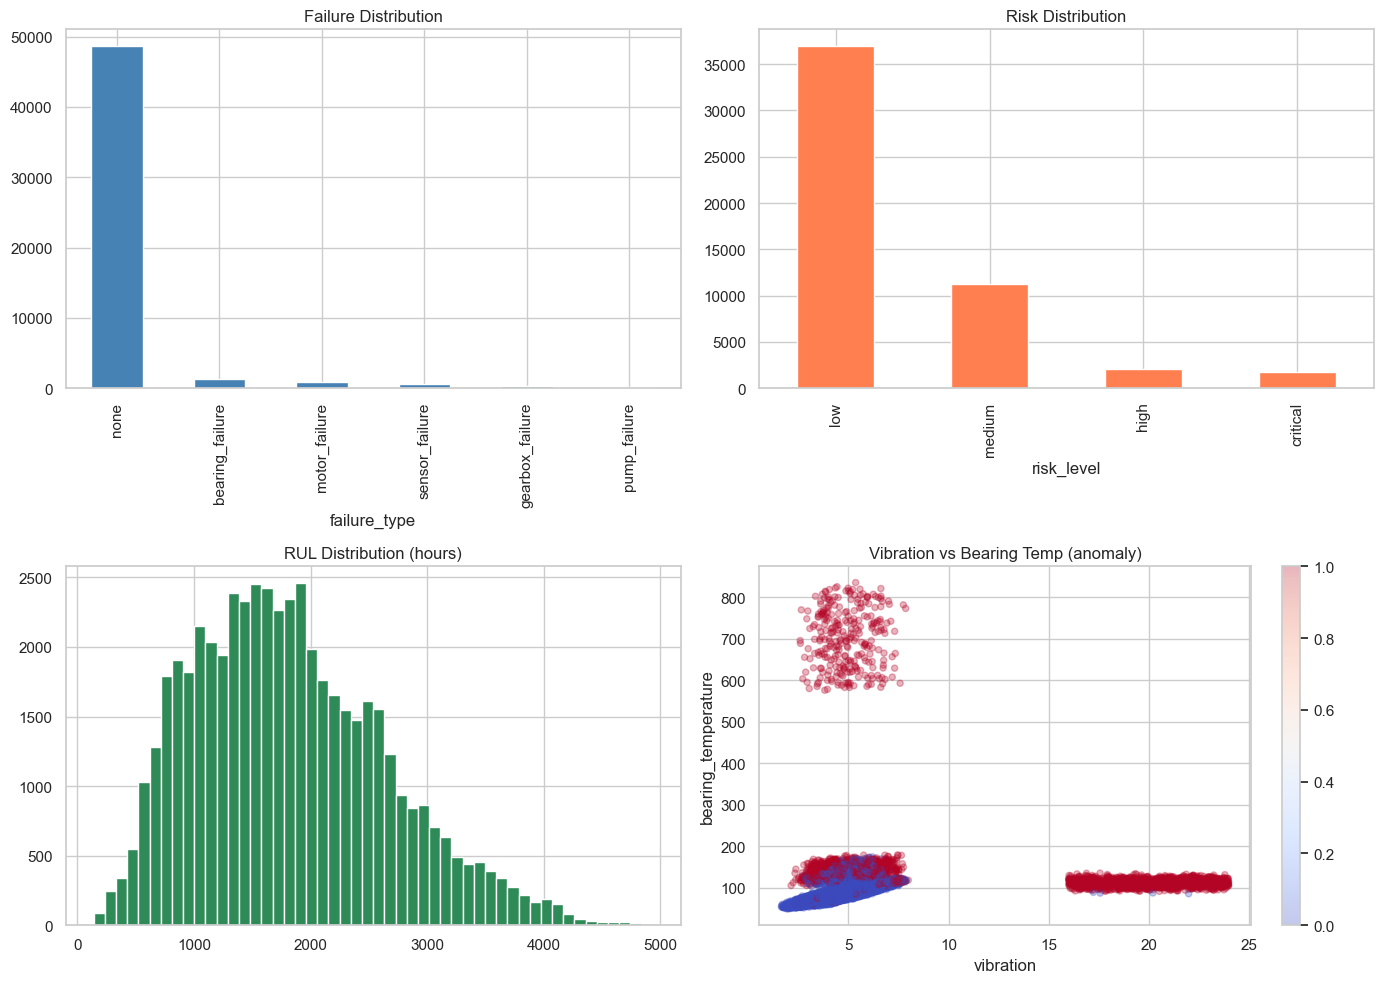

,ds,y
0,2023-01-01,18.217424
1,2023-01-02,19.215656
2,2023-01-03,32.462223
3,2023-01-04,18.879930
4,2023-01-05,16.175713


In [2]:
# --- Data Engineering & EDA ---
master = pd.read_csv(MASTER / "industrial_master.csv", parse_dates=["timestamp"])
print(f"Master records: {len(master):,} | Assets: {master['equipment_id'].nunique()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
master["failure_type"].value_counts().plot(kind="bar", ax=axes[0,0], title="Failure Distribution", color="steelblue")
master["risk_level"].value_counts().plot(kind="bar", ax=axes[0,1], title="Risk Distribution", color="coral")
axes[1,0].hist(master["remaining_useful_life_hours"], bins=50, color="seagreen", edgecolor="white")
axes[1,0].set_title("RUL Distribution (hours)")
master.plot.scatter(x="vibration", y="bearing_temperature", c=master["is_anomaly"], cmap="coolwarm", alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Vibration vs Bearing Temp (anomaly)")
plt.tight_layout()
plt.savefig(DATASETS / MODEL_KEY / "eda_overview.png", dpi=120)
plt.show()

if TRAIN_CSV.exists():
    try:
        from IPython.display import display
        display(pd.read_csv(TRAIN_CSV).head())
    except ImportError:
        print(pd.read_csv(TRAIN_CSV).head())

## 3. Model Training & Evaluation

03:23:08 - cmdstanpy - INFO - Chain [1] start processing


Prophet demand series: 2167 days


03:23:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 11.00 | MAPE: 0.173


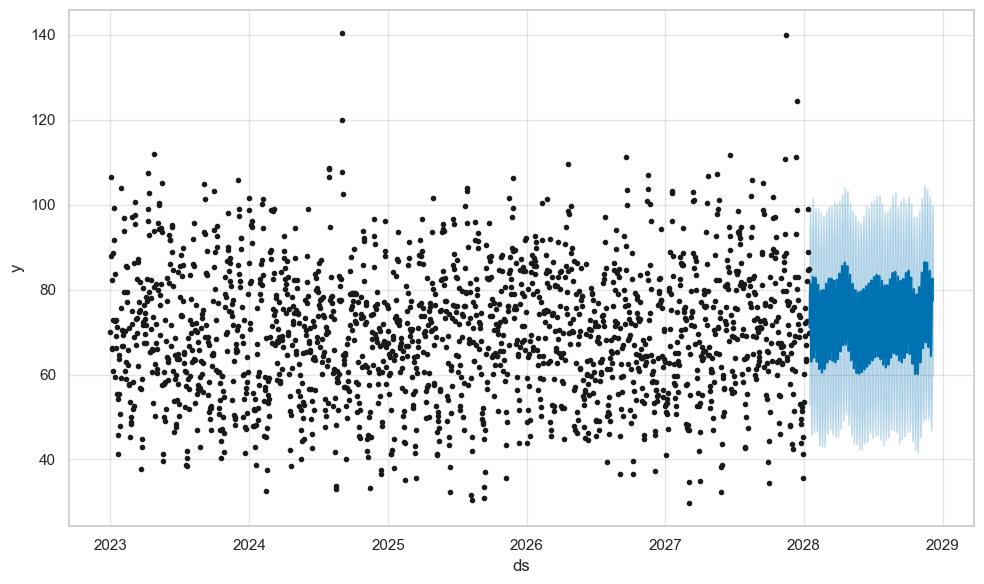

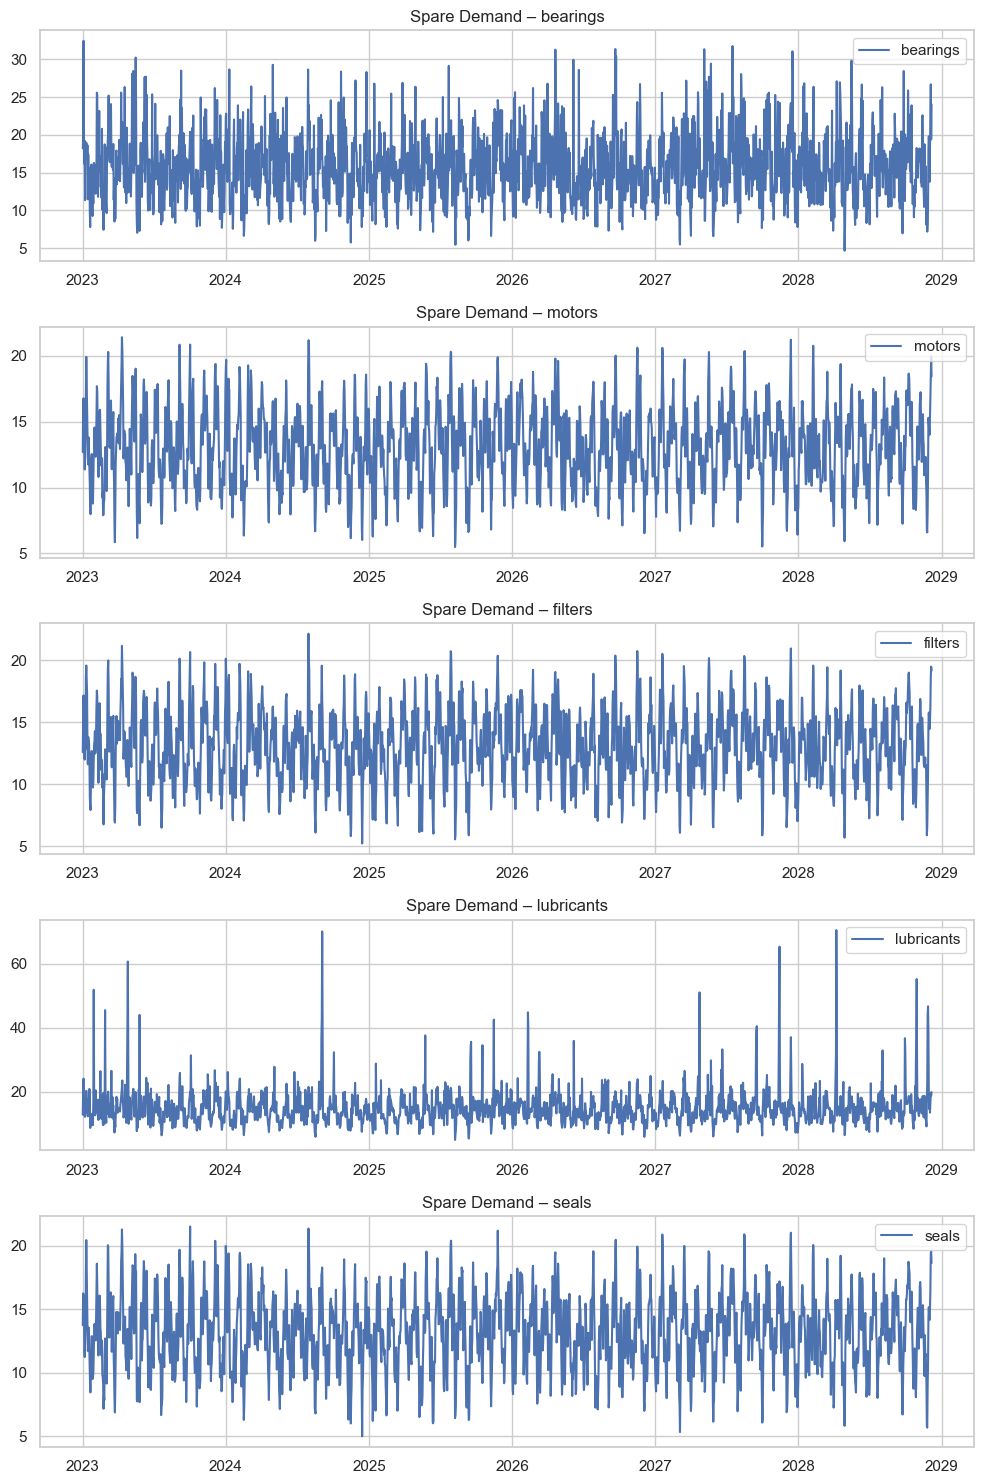

['c:\\Users\\ASUS\\Downloads\\tata-steel-round -2\\industrial-agentic-maintenance-ai\\backend\\artifacts\\prophet_forecast.joblib']

In [ ]:
import joblib
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

cat_dir = DATASETS / MODEL_KEY / "categories"
dfs = [pd.read_csv(p, parse_dates=["ds"]) for p in sorted(cat_dir.glob("*.csv"))]
combined = pd.concat(dfs).groupby("ds", as_index=False)["y"].sum()
split = int(len(combined) * 0.85)
train_df, test_df = combined.iloc[:split], combined.iloc[split:]
print(f"Prophet demand series: {len(combined)} days")

try:
    from prophet import Prophet
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    m.fit(train_df)
    forecast = m.predict(test_df[["ds"]])
    mae = mean_absolute_error(test_df["y"], forecast["yhat"])
    mape = mean_absolute_percentage_error(test_df["y"], forecast["yhat"])
    print(f"Prophet MAE: {mae:.2f} | MAPE: {mape:.3f}")
    fig = m.plot(forecast)
    plt.savefig(DATASETS / MODEL_KEY / "prophet_forecast.png", dpi=120)
    plt.show()
    model = {"prophet_model": m, "baseline": float(train_df["y"].mean())}
except ImportError:
    print("Prophet not installed– using baseline")
    model = {"baseline": float(train_df["y"].mean())}

cat_names = ["bearings","motors","filters","lubricants","seals"]
fig, axes = plt.subplots(len(dfs), 1, figsize=(10, 3 * len(dfs)), squeeze=False)
for ax, cat, pdf in zip(axes[:, 0], cat_names, dfs):
    ax.plot(pdf["ds"], pdf["y"], label=cat)
    ax.set_title(f"Spare Demand – {cat}")
    ax.legend()
plt.tight_layout()
plt.savefig(DATASETS / MODEL_KEY / "spare_demand_all.png", dpi=120)
plt.show()

joblib.dump(model, ARTIFACTS / "prophet_forecast.joblib")

## 4. Pipeline Evaluation Metrics

In [6]:
metrics_path = EVAL / "metrics.json"
if metrics_path.exists():
    all_metrics = json.loads(metrics_path.read_text())
    print(json.dumps(all_metrics.get(MODEL_KEY, {}), indent=2))
else:
    print("Run: python scripts/generate_synthetic_data.py --skip-train  to generate metrics")

{
  "mae_baseline": 3.4882967472076416,
  "mape_baseline": 0.24993406236171722,
  "summary": "MAE=3.49",
  "prophet_note": "Prophet not installed"
}


## 5. Production Deployment

Artifact saved to `backend/artifacts/`. Restart API after retraining:
```bash
cd backend && uvicorn main:app --reload --port 8000
```